# Statistical analysis of lop algorithms implementation

## setup

In [76]:
!uv sync


Resolved 17 packages in 2ms
Audited 14 packages in 0.06ms


In [77]:
import ast
import itertools
import subprocess
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import ttest_rel, wilcoxon


### parameters

In [78]:
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "data" / "input").is_dir() and (PROJECT_ROOT.parent / "data" / "input").is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "analysis" / "benchmark_best_known.py").is_file():
    raise FileNotFoundError(f"Could not locate project root from {Path.cwd()}")

PATH_TO_OUT = PROJECT_ROOT / "data" / "output"
PATH_TO_IN = PROJECT_ROOT / "data" / "input"

PATH_TO_BEST_KNOWN = PATH_TO_IN / "best_known.txt"
PATH_TO_INSTANCES = PATH_TO_IN / "instances"
PATH_TO_OUTPUT_IT_IMP = PATH_TO_OUT / "it_im_results.csv"
PATH_TO_OUTPUT_VND = PATH_TO_OUT / "lop_vnd_results.csv"
PATH_TO_OUTPUT_MEM_PARAM = PATH_TO_OUT / "meme_param_results.csv"
PATH_TO_OUTPUT_MEMETIC = PATH_TO_OUT / "meme_results.csv"
PATH_TO_OUTPUT_ILS = PATH_TO_OUT / "ils_results.csv"
PATH_TO_OUTPUT_ILS_PARAM = PATH_TO_OUT / "ils_param_results.csv"    

PATH_TO_FIGS = PATH_TO_OUT / "figs"

PATH_BENCHMARK = PROJECT_ROOT / "analysis" / "benchmark_best_known.py"

bench_out = {
    "it_im": PATH_TO_OUTPUT_IT_IMP,
    "vnd": PATH_TO_OUTPUT_VND,
    "meme_param": PATH_TO_OUTPUT_MEM_PARAM,
    "meme": PATH_TO_OUTPUT_MEMETIC,
    "ils": PATH_TO_OUTPUT_ILS,
    "ils_param": PATH_TO_OUTPUT_ILS_PARAM,
}

# convenience ordered list for loops
benches = list(bench_out.items())

# benchmark parameters
N_WORKERS = -1
N_RUNS = 1
# Guard to avoid benchmarks
RUN_BENCH = True

### functions

In [79]:
def ensure_benchmark(bench: str, outputs: list[Path]) -> None:
    if all(path.exists() for path in outputs):
        print(f"{bench} benchmark already present. Skipping.")
        return

    if not PATH_BENCHMARK.exists():
        raise FileNotFoundError(f"Benchmark script not found: {PATH_BENCHMARK}")

    # If user has disabled running benchmarks during editing, skip launching them
    global RUN_BENCH
    try:
        run_allowed = bool(RUN_BENCH)
    except NameError:
        run_allowed = False
    if not run_allowed:
        print(f"{bench} CSV missing but RUN_BENCH is False — skipping benchmark run.")
        return

    PATH_TO_OUT.mkdir(parents=True, exist_ok=True)

    cmd = [
        "uv",
        "run",
        str(PATH_BENCHMARK),
        "--bench",
        bench,
        "--instances-dir",
        str(PATH_TO_INSTANCES),
        "--best_known_file",
        str(PATH_TO_BEST_KNOWN),
        "--output",
        str(PATH_TO_OUT),
        "--runs",
        str(N_RUNS),
        "-w",
        str(N_WORKERS),
    ]
    exit_code = subprocess.call(cmd, cwd=PROJECT_ROOT)
    if exit_code != 0:
        raise RuntimeError(f"Benchmark '{bench}' failed.")

In [80]:
RESULT_COLUMNS = [
    "instance",
    "best_known_cost",
    "sol_start",
    "pivot",
    "neighborhoods",
    "cost",
    "time_s",
]

COLUMN_ALIASES = {
    "neighborhood": "neighborhoods",
    "elapsed_seconds": "time_s",
}


def normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    rename_map = {
        src: dst
        for src, dst in COLUMN_ALIASES.items()
        if src in df.columns and dst not in df.columns
    }
    if rename_map:
        df = df.rename(columns=rename_map)
    return df


def parse_neighborhoods(value: object) -> tuple[str, ...]:
    if isinstance(value, (list, tuple)):
        return tuple(str(item) for item in value)
    parsed = ast.literal_eval(str(value))
    if not isinstance(parsed, (list, tuple)):
        raise ValueError(f"Invalid neighborhoods value: {value}")
    return tuple(str(item) for item in parsed)


def load_results(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path).copy()
    df = normalize_columns(df)
    missing = [col for col in RESULT_COLUMNS if col not in df.columns]
    if missing:
        raise ValueError(f"Missing columns in {path}: {missing}")
    df = df[RESULT_COLUMNS].copy()
    df["neighborhood_list"] = df["neighborhoods"].map(parse_neighborhoods)
    df["gap_pct"] = (df["best_known_cost"] - df["cost"]) / df["best_known_cost"] * 100.0
    return df


def run_pairwise_tests(gap_matrix: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for left, right in itertools.combinations(gap_matrix.columns, 2):
        paired = gap_matrix[[left, right]].dropna()
        if paired.empty:
            continue

        left_values = paired[left].to_numpy()
        right_values = paired[right].to_numpy()

        t_stat, t_p_value = ttest_rel(left_values, right_values, alternative="two-sided")

        diff = left_values - right_values
        if np.allclose(diff, 0.0):
            w_stat, w_p_value = 0.0, 1.0
        else:
            w_stat, w_p_value = wilcoxon(
                left_values,
                right_values,
                alternative="two-sided",
                zero_method="wilcox",
            )

        rows.append(
            {
                "algorithm_a": left,
                "algorithm_b": right,
                "n_instances": len(paired),
                "mean_gap_a": left_values.mean(),
                "mean_gap_b": right_values.mean(),
                "ttest_p_value": t_p_value,
                "wilcoxon_p_value": w_p_value,
                "significant_5pct_wilcoxon": w_p_value < 0.05,
            }
        )

    return pd.DataFrame(rows).sort_values("wilcoxon_p_value", ignore_index=True)


In [ ]:
def analyze_benchmark(bench: str, csv_path: Path) -> None:
    print(f"\n--- Processing benchmark: {bench} ---")
    # Run the benchmark only if the expected CSV output is missing
    ensure_benchmark(bench, [csv_path])

    # If benchmark run was skipped and CSV still missing, avoid crashing
    if not csv_path.exists():
        print(f"No CSV found for {bench} at {csv_path}; skipping analysis.")
        return

    # Try the strict loader first; fallback to flexible parsing for param-sweep CSVs
    try:
        df = load_results(csv_path)
    except ValueError as exc:
        print(f"load_results failed: {exc}; using flexible loader for {csv_path}")
        df = pd.read_csv(csv_path).copy()
        df = normalize_columns(df)
        # time column fallback
        if "time_s" not in df.columns and "elapsed_seconds" in df.columns:
            df["time_s"] = df["elapsed_seconds"]
        # neighborhood parsing fallback
        if "neighborhoods" in df.columns:
            df["neighborhood_list"] = df["neighborhoods"].map(parse_neighborhoods)
        elif "neighborhood" in df.columns:
            df["neighborhood_list"] = df["neighborhood"].map(lambda v: (v,))
        else:
            # no neighborhood info available -> empty tuple
            df["neighborhood_list"] = [() for _ in range(len(df))]
        # best-known and cost required
        if "best_known_cost" not in df.columns or "cost" not in df.columns:
            raise ValueError(f"Cannot analyze {csv_path}: missing cost/best-known columns")
        df["gap_pct"] = (df["best_known_cost"] - df["cost"]) / df["best_known_cost"] * 100.0

    if df.empty:
        print(f"No rows for {bench} in {csv_path}")
        return

    # Ensure a consistent `algorithm` column for grouping/plotting
    if "algorithm" not in df.columns:
        if "neighborhood_list" in df.columns:
            def _alg_from_neigh(n):
                try:
                    return " -> ".join(n) if len(n) > 1 else n[0]
                except Exception:
                    return str(n)
            df["algorithm"] = df["neighborhood_list"].map(_alg_from_neigh)
        else:
            df["algorithm"] = (
                df.get("sol_start", "").astype(str)
                + " | "
                + df.get("pivot", "").astype(str)
            )

    summary = (
        df.groupby(["algorithm"], as_index=False)
        .agg(
            avg_gap_pct=("gap_pct", "mean"),
            std_gap_pct=("gap_pct", "std"),
            total_time_s=("time_s", "sum"),
        )
        .sort_values("avg_gap_pct", ignore_index=True)
    )

    summary.to_csv(PATH_TO_OUT / f"{bench}_summary_stats.csv", index=False)

    # Build gap matrix; if duplicate instance/algorithm rows exist, aggregate by mean first
    try:
        gap_matrix = df.pivot(index="instance", columns="algorithm", values="gap_pct")
    except Exception as exc:
        print(f"pivot failed ({exc}); aggregating duplicates by mean before pivot")
        gap_matrix = df.groupby(["instance", "algorithm"], as_index=False)["gap_pct"].mean().pivot(index="instance", columns="algorithm", values="gap_pct")

    if gap_matrix.shape[1] >= 2:
        pairwise = run_pairwise_tests(gap_matrix)
        pairwise.to_csv(PATH_TO_OUT / f"{bench}_pairwise_tests.csv", index=False)

    display(summary)

    PATH_TO_FIGS.mkdir(parents=True, exist_ok=True)
    order = summary["algorithm"].tolist()

    fig, ax = plt.subplots(figsize=(6, 6), constrained_layout=True)
    ax.boxplot(
        [df.loc[df["algorithm"] == algo, "gap_pct"] for algo in order],
        tick_labels=order,
        showmeans=True,
    )
    ax.set_title(f"{bench}: instance-wise deviation distribution")
    ax.set_ylabel("Deviation from best-known (%)")
    ax.set_xlabel("Algorithm")
    ax.tick_params(axis="x", rotation=45)

    fig.savefig(PATH_TO_FIGS / f"{bench}_boxplot.svg", format="svg")
    plt.show()

print("Note: RUN_BENCH flag controls whether missing CSVs will be computed. It is currently:", RUN_BENCH)

Note: RUN_BENCH flag controls whether missing CSVs will be computed. It is currently: True


## Iterative improvement
Run benchmarks of iterative improvement 'it_imp'.

it_imp benchmark already present. Skipping.


,sol_start,pivot,neighborhood,algorithm,avg_gap_pct,std_gap_pct,total_time_s
0,c_and_w,first,exchange,c_and_w | first | exchange,2.679405,0.456327,508.147613
1,random,first,exchange,random | first | exchange,2.870286,0.514272,576.424382
2,c_and_w,best,insert,c_and_w | best | insert,3.129755,0.493551,155.453130
3,random,best,insert,random | best | insert,3.511592,0.514242,183.001680
4,c_and_w,best,exchange,c_and_w | best | exchange,3.639035,0.642606,88.789658
5,random,best,exchange,random | best | exchange,3.648876,0.545486,97.838254
6,c_and_w,first,insert,c_and_w | first | insert,4.056011,0.598467,176.153706
7,random,first,insert,random | first | insert,4.071977,0.590712,171.708743
8,c_and_w,best,transpose,c_and_w | best | transpose,21.990696,2.402308,0.023079
9,c_and_w,first,transpose,c_and_w | first | transpose,22.088517,2.362936,0.008443


,algorithm_a,algorithm_b,n_instances,mean_gap_a,mean_gap_b,ttest_p_value,wilcoxon_p_value,significant_5pct_wilcoxon
0,c_and_w | first | transpose,random | first | transpose,62,22.088517,34.939937,1.865527e-32,7.577765e-12,True
1,c_and_w | best | exchange,c_and_w | best | transpose,61,3.639035,21.990696,1.314578e-56,1.111165e-11,True
2,c_and_w | best | exchange,random | best | transpose,61,3.639035,34.888936,1.286707e-56,1.111165e-11,True
3,c_and_w | best | exchange,c_and_w | first | transpose,61,3.639035,22.078347,7.305781e-57,1.111165e-11,True
4,c_and_w | best | exchange,random | first | transpose,61,3.639035,34.986143,1.310461e-56,1.111165e-11,True
5,c_and_w | best | insert,c_and_w | first | transpose,61,3.129755,22.078347,5.124078e-58,1.111165e-11,True
6,c_and_w | best | transpose,random | first | transpose,61,21.990696,34.986143,6.117404e-32,1.111165e-11,True
7,c_and_w | best | insert,c_and_w | best | transpose,61,3.129755,21.990696,8.514785e-58,1.111165e-11,True
8,c_and_w | best | transpose,random | best | exchange,61,21.990696,3.648876,2.186532e-56,1.111165e-11,True
9,c_and_w | best | transpose,random | best | insert,61,21.990696,3.511592,1.692864e-55,1.111165e-11,True


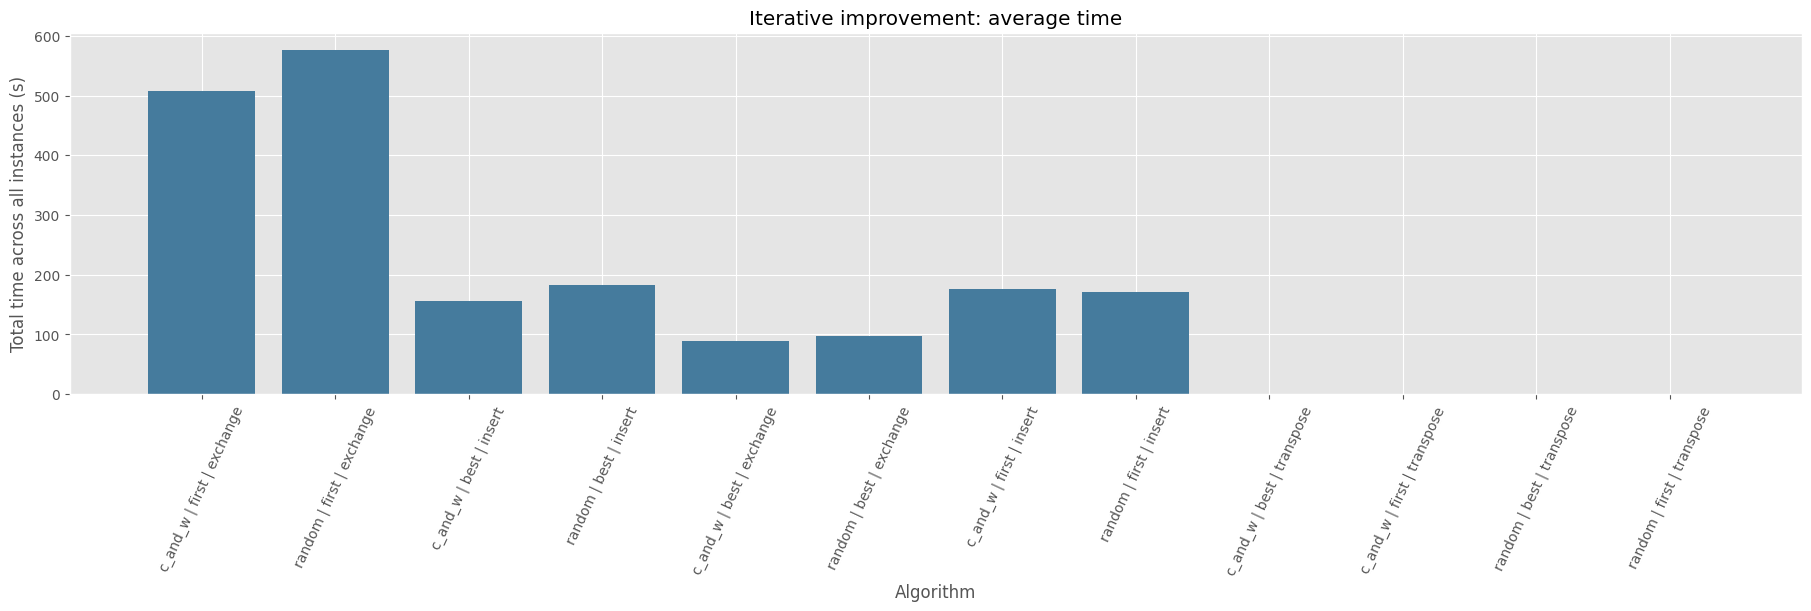

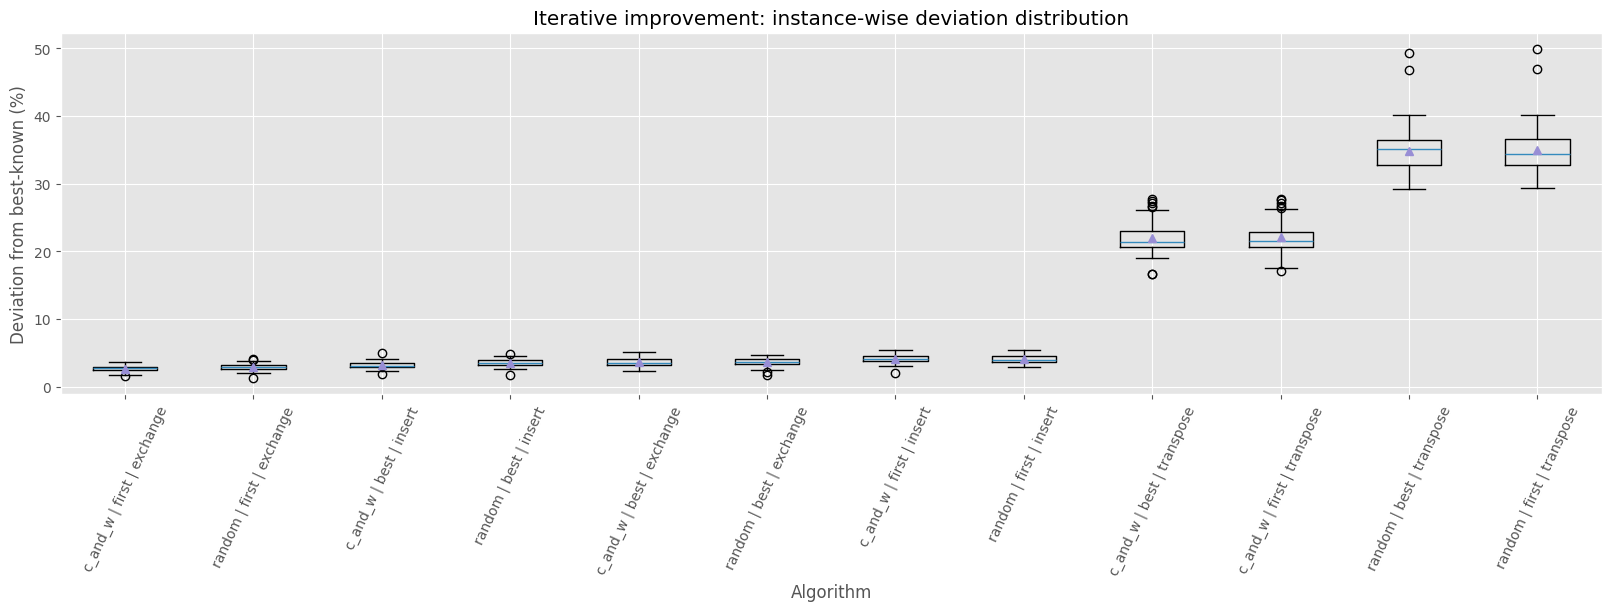

In [82]:
ensure_benchmark("it_imp", [PATH_TO_OUTPUT_IT_IMP])

df_it_imp = load_results(PATH_TO_OUTPUT_IT_IMP)
df_it_imp = df_it_imp[df_it_imp["neighborhood_list"].str.len() == 1].copy()
if df_it_imp.empty:
    raise ValueError("No iterative improvement rows found in it_im_results.csv.")

df_it_imp["neighborhood"] = df_it_imp["neighborhood_list"].str[0]
df_it_imp["algorithm"] = (
    df_it_imp["sol_start"] + " | " + df_it_imp["pivot"] + " | " + df_it_imp["neighborhood"]
)

it_summary = (
    df_it_imp.groupby(["sol_start", "pivot", "neighborhood", "algorithm"], as_index=False)
    .agg(
        avg_gap_pct=("gap_pct", "mean"),
        std_gap_pct=("gap_pct", "std"),
        total_time_s=("time_s", "sum"),
    )
    .sort_values(["avg_gap_pct", "total_time_s"], ignore_index=True)
)
it_summary.to_csv(PATH_TO_OUT / "it_im_summary_stats.csv", index=False)

it_gap_matrix = df_it_imp.pivot(index="instance", columns="algorithm", values="gap_pct")
it_pairwise_tests = run_pairwise_tests(it_gap_matrix)
it_pairwise_tests.to_csv(PATH_TO_OUT / "it_im_pairwise_tests.csv", index=False)

display(it_summary)
display(it_pairwise_tests.head(20))

plt.style.use("ggplot")  # emulate R style
PATH_TO_FIGS.mkdir(parents=True, exist_ok=True)

it_plot = it_summary.sort_values("avg_gap_pct")
it_order = it_plot["algorithm"].tolist()

fig_it_summary, axes = plt.subplots(figsize=(18, 6), constrained_layout=True)
axes.bar(it_plot["algorithm"], it_plot["total_time_s"], color="#457b9d")
axes.set_title("Iterative improvement: average time")
axes.set_ylabel("Total time across all instances (s)")
axes.set_xlabel("Algorithm")
axes.tick_params(axis="x", rotation=65)

fig_it_summary.savefig(PATH_TO_FIGS / "it_imp_summary.svg", format="svg")
plt.show()

fig_it_box, ax = plt.subplots(figsize=(16, 6), constrained_layout=True)
ax.boxplot(
    [df_it_imp.loc[df_it_imp["algorithm"] == algo, "gap_pct"] for algo in it_order],
    tick_labels=it_order,
    showmeans=True,
)
ax.set_title("Iterative improvement: instance-wise deviation distribution")
ax.set_ylabel("Deviation from best-known (%)")
ax.set_xlabel("Algorithm")
ax.tick_params(axis="x", rotation=65)
fig_it_box.savefig(PATH_TO_FIGS / "it_imp_boxplot.svg", format="svg")
plt.show()


## Variable neighborhood descent (VND) algorithm

vnd benchmark already present. Skipping.


,algorithm,avg_gap_pct,std_gap_pct,total_time_s
0,transpose -> exchange -> insert,2.297919,0.457472,1171.626290
1,transpose -> insert -> exchange,3.485551,0.606711,521.951438


,algorithm_a,algorithm_b,n_instances,mean_gap_a,mean_gap_b,ttest_p_value,wilcoxon_p_value,significant_5pct_wilcoxon
0,transpose -> exchange -> insert,transpose -> insert -> exchange,78,2.297919,3.485551,1.217030e-24,3.371464e-14,True


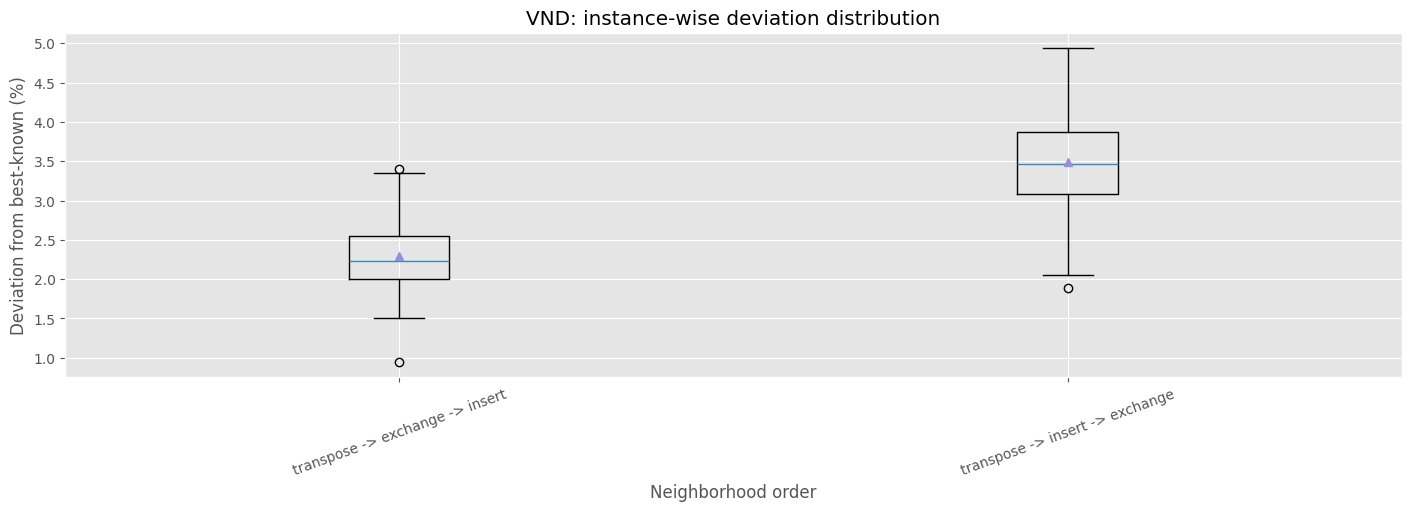

In [ ]:
ensure_benchmark("vnd", [PATH_TO_OUTPUT_VND])

df_vnd = load_results(PATH_TO_OUTPUT_VND)
df_vnd = df_vnd[df_vnd["neighborhood_list"].str.len() > 1].copy()
if df_vnd.empty:
    raise ValueError("No VND rows found in lop_vnd_results.csv.")

df_vnd["algorithm"] = df_vnd["neighborhood_list"].map(lambda n: " -> ".join(n))

vnd_summary = (
    df_vnd.groupby(["algorithm"], as_index=False)
    .agg(
        avg_gap_pct=("gap_pct", "mean"),
        std_gap_pct=("gap_pct", "std"),
        total_time_s=("time_s", "sum"),
    )
    .sort_values("avg_gap_pct", ignore_index=True)
)
vnd_summary.to_csv(PATH_TO_OUT / "vnd_summary_stats.csv", index=False)

vnd_gap_matrix = df_vnd.pivot(index="instance", columns="algorithm", values="gap_pct")
if vnd_gap_matrix.shape[1] != 2:
    raise ValueError(f"Expected exactly 2 VND algorithms, got {vnd_gap_matrix.shape[1]}")

vnd_a, vnd_b = vnd_gap_matrix.columns
vnd_paired = vnd_gap_matrix[[vnd_a, vnd_b]].dropna()

vnd_t_stat, vnd_t_p_value = ttest_rel(vnd_paired[vnd_a], vnd_paired[vnd_b], alternative="two-sided")
vnd_diff = vnd_paired[vnd_a].to_numpy() - vnd_paired[vnd_b].to_numpy()
if np.allclose(vnd_diff, 0.0):
    vnd_w_stat, vnd_w_p_value = 0.0, 1.0
else:
    vnd_w_stat, vnd_w_p_value = wilcoxon(
        vnd_paired[vnd_a],
        vnd_paired[vnd_b],
        alternative="two-sided",
        zero_method="wilcox",
    )

vnd_test = pd.DataFrame(
    [
        {
            "algorithm_a": vnd_a,
            "algorithm_b": vnd_b,
            "n_instances": len(vnd_paired),
            "mean_gap_a": vnd_paired[vnd_a].mean(),
            "mean_gap_b": vnd_paired[vnd_b].mean(),
            "ttest_p_value": vnd_t_p_value,
            "wilcoxon_p_value": vnd_w_p_value,
            "significant_5pct_wilcoxon": vnd_w_p_value < 0.05,
        }
    ]
)

vnd_test.to_csv(PATH_TO_OUT / "vnd_stat_test.csv", index=False)

display(vnd_summary)
display(vnd_test)

PATH_TO_FIGS.mkdir(parents=True, exist_ok=True)

vnd_order = vnd_summary["algorithm"].tolist()
fig_vnd, axes = plt.subplots(figsize=(5, 5), constrained_layout=True)


axes.boxplot(
    [df_vnd.loc[df_vnd["algorithm"] == algo, "gap_pct"] for algo in vnd_order],
    tick_labels=vnd_order,
    showmeans=True,
)
axes.set_title("VND: instance-wise deviation distribution")
axes.set_ylabel("Deviation from best-known (%)")
axes.set_xlabel("Neighborhood order")
axes.tick_params(axis="x", rotation=20)

fig_vnd.savefig(PATH_TO_FIGS / "vnd_summary.svg", format="svg")
plt.show()


## iterative local search (ILS) algorithm

### parameters
Run 'meme_param' benchmark and compare the results. This allow to visualize the effect of the parameters on the solution quality. Only on instances is used to reduce computation time.


--- Processing benchmark: ils_param ---
ils_param benchmark already present. Skipping.
pivot failed (Index contains duplicate entries, cannot reshape); aggregating duplicates by mean before pivot


/var/home/quatras/Desktop/heuristic/heuristic_optimization_lop/.venv/lib/python3.12/site-packages/scipy/stats/_stats_py.py:1251: RuntimeWarning: divide by zero encountered in divide
  var *= (n / (n-ddof))  # to avoid error on division by zero
/var/home/quatras/Desktop/heuristic/heuristic_optimization_lop/.venv/lib/python3.12/site-packages/scipy/stats/_stats_py.py:1251: RuntimeWarning: invalid value encountered in scalar multiply
  var *= (n / (n-ddof))  # to avoid error on division by zero


,algorithm,avg_gap_pct,std_gap_pct,total_time_s
0,transpose -> exchange -> insert,2.476910,0.142699,2210.949424
1,exchange,3.173743,0.518765,1660.922517


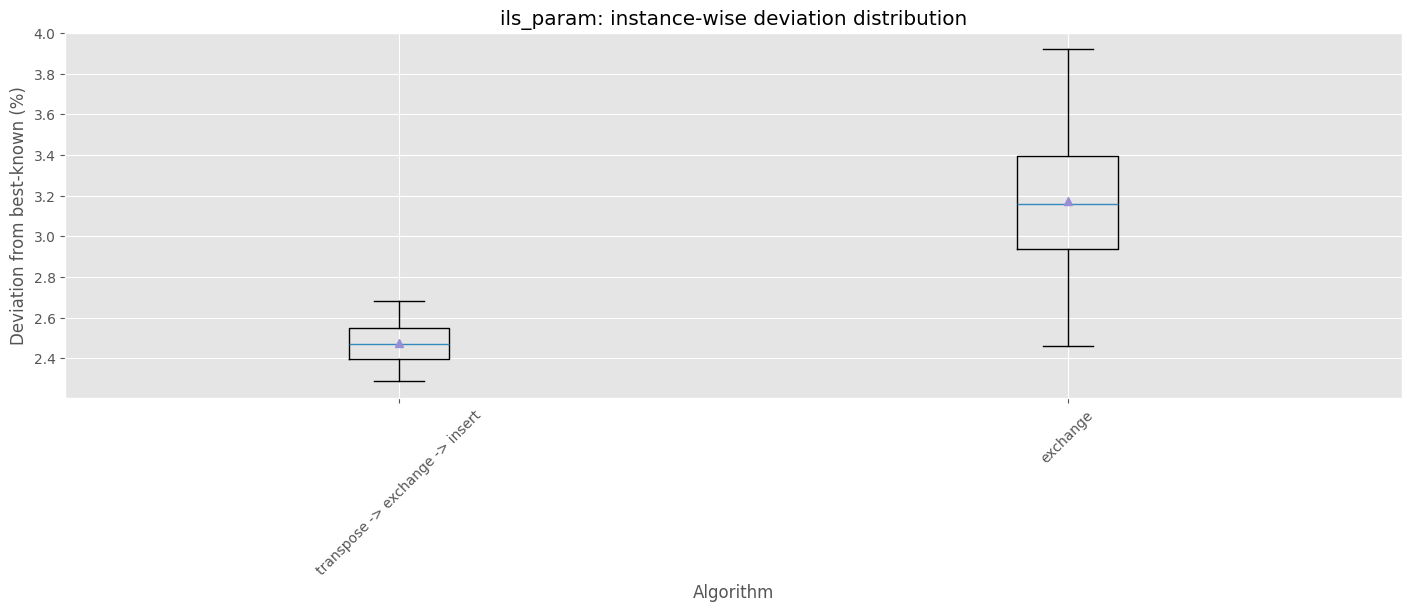

In [84]:
analyze_benchmark("ils_param", bench_out["ils_param"])

### instances
Run 'memetic' benchmark on all instances of size 150 and show the deviation from best known solution.

In [85]:
analyze_benchmark("ils", bench_out["ils"])


--- Processing benchmark: ils ---


this computer has 8 CPU cores
-1
Auto-detected 8 cores. assigning 7 workers for benchmark (all CPUs minus -7)
7 processes allocated


benchmark:   0%|          | 5/39936 [00:07<14:07:27,  1.27s/run, N-be75eec_150 algo=ils sol_start=random pivot=first neighborhood=['exchange'] ils_perturb_rate=0 ils_n_try=0 ils_worst=10000]

benchmark:   0%|          | 25/39936 [00:48<70:21:03,  6.35s/run, N-be75eec_150 algo=ils sol_start=random pivot=first neighborhood=['exchange'] ils_perturb_rate=0.1 ils_n_try=1 ils_worst=10000]Process ForkProcess-2:
Process ForkProcess-7:
Traceback (most recent call last):
  File "/var/home/quatras/.local/share/uv/python/cpython-3.12.6-linux-x86_64-gnu/lib/python3.12/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/var/home/quatras/.local/share/uv/python/cpython-3.12.6-linux-x86_64-gnu/lib/python3.12/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/var/home/quatras/.local/share/uv/python/cpython-3.12.6-linux-x86_64-gnu/lib/python3.12/concurrent/futures/process.py", line 251, in _process_worker
    call_item = call_queue.get(block=True)
                ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/var/home/quatras/.local/share/uv/python/cpython-3.12.6-linux-x86_64-gnu/lib/python3.12/multiprocessing/queues.py", line 10

KeyboardInterrupt: 

## Memetic algorithm
First make the 'meme_param' benchmark, to determine the best parameters for the memetic algorithm. Then run the memetic algorithm with the `memetic` benchmark on all instances of size 150 and analyze the results.

### Parameters
Run 'meme_param' benchmark and compare the results. 

In [ ]:
analyze_benchmark("meme_param", bench_out["meme_param"])


--- Processing benchmark: meme_param ---
meme_param benchmark already present. Skipping.
load_results failed: Missing columns in /var/home/quatras/Desktop/heuristic/heuristic_optimization_lop/data/output/meme_param_results.csv: ['sol_start']; using flexible loader for /var/home/quatras/Desktop/heuristic/heuristic_optimization_lop/data/output/meme_param_results.csv
No rows for meme_param in /var/home/quatras/Desktop/heuristic/heuristic_optimization_lop/data/output/meme_param_results.csv


### instances
Run 'memetic' benchmark to measure the deviation from best known on all instances of size 150.

In [ ]:

analyze_benchmark("meme", bench_out["meme"])


--- Processing benchmark: meme ---
meme benchmark already present. Skipping.
load_results failed: No columns to parse from file; using flexible loader for /var/home/quatras/Desktop/heuristic/heuristic_optimization_lop/data/output/meme_results.csv


EmptyDataError: No columns to parse from file